## Task 1 Imputing and Encoding


In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Decision tree
from sklearn.tree import DecisionTreeClassifier


# Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [13]:
# Read in data
df = pd.read_csv('train.csv')

In [14]:
# Let's choose some features
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]]
y = df["Survived"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [15]:
# Find if here are any missing values
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [16]:
# Age has a lot of NaN, which stands for Not a Number, and we see in the csv that these are just empty and not available. Embarked has a couple
# We can choose to ignore those rows

X_remove_nan = X.dropna()
X_remove_nan.info()
X_remove_nan.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    712 non-null    int64  
 1   Sex       712 non-null    object 
 2   Age       712 non-null    float64
 3   SibSp     712 non-null    int64  
 4   Parch     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 44.5+ KB


,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [17]:
# we can also choose to impute the values
X_imputed = X.copy()
X_imputed["Age"] = X_imputed["Age"].fillna(X["Age"].mean())

X_imputed["Embarked"] = X_imputed["Embarked"].fillna("Not Known")
X_imputed.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
# "Sex" and "Embarked" are categorical values, we need to use One Hot Encoding to make them numerical values
X_imputed_encoded = pd.get_dummies(X_imputed, columns=['Sex', 'Embarked'], drop_first=True)
display(X_imputed_encoded.head())

In [18]:
# Repeat for X_removed

In [ ]:
dt = DecisionTreeClassifier()


In [ ]:
rf = RandomForestClassifier(n_estimators=100)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.show()

### Please check canvas for actual tasks

## Task 2 Naive Bayes and Logistic Regression

### Understanding probabilities from NB

In [ ]:
### load iris
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

In [ ]:
# Split into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
# use naive bayes for classification
from sklearn.naive_bayes import GaussianNB

In [ ]:
# Plotting code for probabilities from Gaussian NB
def plot_distribution(X, model):
  # Note X is only used here to get the min and max limits for each feature
  num_features = len(feature_names)
  plot_features = feature_names
  nspace = 100


  for feature_index in range(num_features):
      feature_name = feature_names[feature_index]
      x_vals = np.linspace(np.min(X[:, feature_index])*0.8, np.max(X[:, feature_index])*1.2, nspace)

      # x_vals = np.linspace(pre_df[[feature_name]].min(), pre_df[[feature_name]].max(), 200)


      if feature_name in plot_features:
        plt.figure(figsize=(8, 4))

        for cls in range(3):
            mean = model.theta_[cls, feature_index]
            std = np.sqrt(model.var_[cls, feature_index])
            # print(mean, std)
            y_vals = norm.pdf(x_vals, mean, std)
            plt.plot(x_vals, y_vals, label=f"Class {cls} ({target_names[cls]})")

        plt.title(f"Gaussian Distribution - {feature_name}")
        plt.xlabel(feature_name)
        plt.ylabel("Probability Density")
        plt.legend()
        plt.grid(True)

        plt.show()

In [ ]:
# Usage
plot_distribution(X, nb)

### Understanding probabilities from LR

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=...)


In [ ]:
# Plotting code to interpret probabilites from LR
y_prob = lr.predict_proba(X_test)
plt.subplot(3,1,1)
plt.plot(y_prob[y_test==0, 0], label="Class 0 prob", linestyle='None', marker='o', color="r")
plt.plot(y_prob[y_test==0, 1], label="Class 1 prob", linestyle='None', marker='o', color="b")
plt.plot(y_prob[y_test==0, 2], label="Class 2 prob", linestyle='None', marker='o', color="g")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Actual class 0")

plt.subplot(3,1,2)
plt.plot(y_prob[y_test==1, 0], label="Class 0 prob", linestyle='None', marker='o', color="r")
plt.plot(y_prob[y_test==1, 1], label="Class 1 prob", linestyle='None', marker='o', color="b")
plt.plot(y_prob[y_test==1, 2], label="Class 2 prob", linestyle='None', marker='o', color="g")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Actual class 1")

plt.subplot(3,1,3)
plt.plot(y_prob[y_test==2, 0], label="Class 0 prob", linestyle='None', marker='o', color="r")
plt.plot(y_prob[y_test==2, 1], label="Class 1 prob", linestyle='None', marker='o', color="b")
plt.plot(y_prob[y_test==2, 2], label="Class 2 prob", linestyle='None', marker='o', color="g")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Actual class 2")

plt.show()

### Please refer to canvas for items to complete for this task

## Task 3 Neural Networks

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load the digits dataset (a common dataset used as a simpler alternative to MNIST)
digits = load_digits()
X = digits.data
y = digits.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

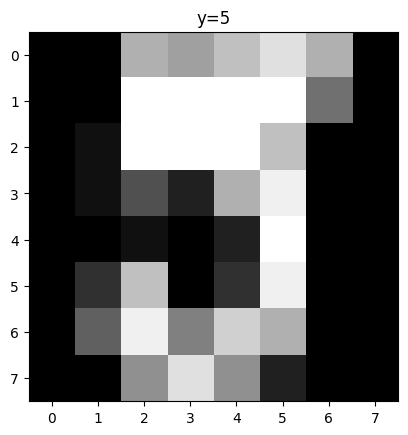

In [4]:
# Plot a sample
import matplotlib.pyplot as plt
plt.imshow(X_train[0].reshape(8, 8), cmap='gray')

plt.title(f"y={y_train[0]}")
plt.show()

In [7]:
# Notice that while we convert to 8x8 for plotting purposes, the neural network uses the unwrapped vector as input
X_train[0].shape

(64,)

### Please refer to canvas for items to complete for this task

## For fun: Here is a simple CNN implementation using PyTorch. Feel free to play with it.

Extra credit [10 points] Try some hyper parameter tuning for this CNN model.

In [8]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np

# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train.astype(np.float32)).view(-1, 1, 8, 8)  # Reshape to (batch, channels, height, width)
y_train_tensor = torch.tensor(y_train.astype(np.int64))
X_test_tensor = torch.tensor(X_test.astype(np.float32)).view(-1, 1, 8, 8)
y_test_tensor = torch.tensor(y_test.astype(np.int64))

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define a simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 2 * 2, 10)  # Output for 10 digits (0-9)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 32 * 2 * 2) # Flatten the tensor
        x = self.fc1(x)
        return x

# Instantiate the model, loss function, and optimizer
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}")

# Evaluate the model
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%')

Epoch 1/10, Loss: 1.9933
Epoch 2/10, Loss: 1.0734
Epoch 3/10, Loss: 0.4951
Epoch 4/10, Loss: 0.2799
Epoch 5/10, Loss: 0.1813
Epoch 6/10, Loss: 0.1429
Epoch 7/10, Loss: 0.1004
Epoch 8/10, Loss: 0.0824
Epoch 9/10, Loss: 0.0683
Epoch 10/10, Loss: 0.0541
Accuracy of the model on the test images: 97.50%


To visualize the layers of your `model_augmented` (the `SimpleCNN` instance), you can iterate through its `named_modules()` to get both the name and the module itself, or `children()` to get only the direct child modules.

In [10]:
print("Layers in the SimpleCNN model_augmented:")
for name, module in model.named_modules():
    # Skip the top-level container itself
    if name == '':
        continue
    print(f"Name: {name}, Type: {module.__class__.__name__}")

Layers in the SimpleCNN model_augmented:
Name: conv1, Type: Conv2d
Name: relu1, Type: ReLU
Name: pool1, Type: MaxPool2d
Name: conv2, Type: Conv2d
Name: relu2, Type: ReLU
Name: pool2, Type: MaxPool2d
Name: fc1, Type: Linear
